# RQ3 — corrupting the detector (streaming attacks)

Suppress and force-false on the adaptive coupled system, plus the manufactured-novelty gate duality and a durability check.


In [1]:
import os, sys, copy
from typing import Callable

sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.experiments.contrastive_ncm import (
    load_cicids2017,
    prepare_temporal_split,
    BaseLearnerMLP,
    train_base_learner,
    eval_base_learner,
    ConceptBuffer,
    BatchResult,
    StaticDStaticM,
    StaticDAdaptiveM,
    AdaptiveDAdaptiveM,
    run_stream,
    initial_training,
    apply_paper_style,
    save_fig,
    save_latex,
    agg,
    DAY_NAMES_DEFAULT,
)
from src.detectors.contrastive_ncm import ContrastiveNCMDetector

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')

DATA_DIR = os.path.abspath('../../data/CICIDS2017_Engelen')
FIGURE_DIR = os.path.abspath('./figures')
TABLE_DIR = os.path.abspath('./tables')

NOVEL_CLASSES = ['DoS', 'PortScan']

DD_RETRAIN_EPOCHS = 300
DD_RETRAIN_LR = 1e-4
DD_EVAL_POOL_N = 2000

CONCEPT_BATCH = 256
BATCH_SIZE = 1_000

POISON_FRACS = [0.0, 0.05, 0.20, 0.35]

N_SEEDS = 3
SEEDS = [RANDOM_SEED + 1000 + i for i in range(N_SEEDS)]

# Inherited M hyperparameters (mirror RQ2)
M_HIDDEN = (256, 128, 64)

apply_paper_style()

print(f'Device        : {DEVICE}')
print(f'Novel classes : {NOVEL_CLASSES}')
print(f'Poison fracs  : {POISON_FRACS}')
print(f'Seeds         : {SEEDS}  (N={N_SEEDS})')
print(f'DD retrain    : {DD_RETRAIN_EPOCHS} epochs @ lr={DD_RETRAIN_LR}')
print(f'Figures -> {FIGURE_DIR}')
print(f'Tables  -> {TABLE_DIR}')


# --- Output verbosity: set PROGRESS=False for short, clean saved notebooks ---
from src.experiments.contrastive_ncm import set_progress, set_stream_verbose
PROGRESS = False  # True = live tqdm bars + per-fire stream diagnostics
set_progress(PROGRESS)
set_stream_verbose(PROGRESS)

Device        : cuda
Novel classes : ['DoS', 'PortScan']
Poison fracs  : [0.0, 0.05, 0.2, 0.35]
Seeds         : [1042, 1043, 1044]  (N=3)
DD retrain    : 300 epochs @ lr=0.0001
Figures -> /home/azureuser/final-year-project-dbs21/experiments/contrastive_ncm/figures
Tables  -> /home/azureuser/final-year-project-dbs21/experiments/contrastive_ncm/tables


/home/azureuser/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and split


In [2]:
print('Loading CICIDS2017...')
data = load_cicids2017(DATA_DIR)
print(f'  Rows: {len(data.X):,}  Features: {data.input_dim}')

print('Building temporal split...')
split = prepare_temporal_split(
    data,
    novel_classes=NOVEL_CLASSES,
    per_class_metric_names=NOVEL_CLASSES,  # creates fnr_dos and fnr_portscan masks
    random_seed=RANDOM_SEED,
)
print(f'  Training : {len(split.X_tr):,}  ({split.n_known} known classes)')
print(f'  Eval     : {len(split.X_eval):,}')
print(f'  Stream   : {len(split.X_stream):,}')
print(f'  Novel pool: {len(split.novel_pool):,}')
print()
DAY_NAMES = DAY_NAMES_DEFAULT
for didx, dname in enumerate(DAY_NAMES):
    mask = split.d_stream == didx
    if not mask.any():
        continue
    n_nov = np.isin(split.y_stream, split.novel_ids).sum() if mask.any() else 0
    n_nov_d = np.isin(split.y_stream[mask], split.novel_ids).sum()
    print(f'  {dname}: {mask.sum():>7,} ({100*n_nov_d/mask.sum():.1f}% novel)')


Loading CICIDS2017...


  Rows: 2,100,814  Features: 77
Building temporal split...


  Training : 1,327,413  (7 known classes)
  Eval     : 10,000
  Stream   : 763,401
  Novel pool: 330,930

  Mon:  92,083 (0.0% novel)
  Tue:  79,181 (0.0% novel)
  Wed: 249,496 (67.8% novel)
  Thu:  89,878 (0.0% novel)
  Fri: 252,763 (62.0% novel)


## Initial training


In [3]:
print('Initial training (DD 300 epochs + M 100 epochs + calibration + exemplars)...')
init = initial_training(
    X_tr=split.X_tr,
    y_tr_mc=split.y_tr_mc,
    y_tr_bin=split.y_tr_bin,
    n_known=split.n_known,
    input_dim=data.input_dim,
    device=DEVICE,
    random_seed=RANDOM_SEED,
)
print(f'drift_threshold     = {init.drift_threshold:.4f}')
print(f'concept_threshold T = {init.concept_threshold:.4f}')
print(
    f'Known exemplars: {len(init.X_exemplars):,}  '
    f'(binary {dict(zip(*np.unique(init.y_exemplars, return_counts=True)))}; '
    f'multi-class {dict(zip(*np.unique(init.y_exemplars_mc, return_counts=True)))})'
)

# Initial-state evaluation
m0 = eval_base_learner(
    init.base_learner,
    split.X_eval,
    split.y_eval_bin,
    split.novel_mask_eval,
    split.per_class_masks,
)
print(f'\nPost-initial M  accuracy={m0["accuracy"]:.3f}  f1={m0["f1"]:.3f}')
print(f'  FNR novel = {m0["fnr_novel"]:.3f}')
for k, v in m0.items():
    if k.startswith('fnr_') and k != 'fnr_novel':
        print(f'  {k:15s} = {v:.3f}')


Initial training (DD 300 epochs + M 100 epochs + calibration + exemplars)...


    [Contrastive 20/300] loss=0.1477


    [Contrastive 40/300] loss=0.0835


    [Contrastive 60/300] loss=0.0492


    [Contrastive 80/300] loss=0.0359


...

    [M 40/100] loss=0.0004


    [M 60/100] loss=0.0002


    [M 80/100] loss=0.0002


    [M 100/100] loss=0.0005


drift_threshold     = 1.3339
concept_threshold T = 37.8378
Known exemplars: 2,174  (binary {np.int64(0): np.int64(500), np.int64(1): np.int64(1674)}; multi-class {np.int64(0): np.int64(500), np.int64(1): np.int64(500), np.int64(2): np.int64(500), np.int64(3): np.int64(8), np.int64(4): np.int64(24), np.int64(5): np.int64(500), np.int64(6): np.int64(142)})

Post-initial M  accuracy=0.531  f1=0.207
  FNR novel = 0.937
  fnr_dos         = 0.881
  fnr_portscan    = 0.999


## Detector evaluation pool


In [4]:
_rng_pool = np.random.default_rng(RANDOM_SEED + 7)
pool_idx = _rng_pool.choice(len(split.novel_pool), DD_EVAL_POOL_N, replace=False)
X_dd_eval_pool = split.novel_pool[pool_idx]
print(
    f'DD eval pool: {len(X_dd_eval_pool):,} samples '
    f'(hash for reproducibility check: {hash(X_dd_eval_pool.tobytes()):x})'
)

# Sanity check: DD drift rate on pool at initial state
with torch.no_grad():
    _, _is_dr, _ = init.detector.detect(torch.from_numpy(X_dd_eval_pool))
print(f'Initial DD drift rate on pool: {100*_is_dr.float().mean():.1f}%')
print('(Must be > 0 for the corruption claim to be testable)')


DD eval pool: 2,000 samples (hash for reproducibility check: 315503bae75dbf6e)
Initial DD drift rate on pool: 30.6%
(Must be > 0 for the corruption claim to be testable)


## Baselines


In [5]:
def fresh_static_dd_adaptive_m():
    """Reconstruct a fresh StaticDAdaptiveM from the cached initial state."""
    det = ContrastiveNCMDetector(
        input_dim=data.input_dim,
        hidden_dim=64,
        latent_dim=32,
        temperature=0.1,
        device=DEVICE,
    )
    det.autoencoder.load_state_dict(copy.deepcopy(init.dd_init_ae))
    det.ncm = copy.deepcopy(init.dd_init_ncm)
    det.drift_threshold = init.drift_threshold
    det.concept_threshold = init.concept_threshold
    det.num_classes = split.n_known
    det._reset_drift_buffer()
    ml = BaseLearnerMLP(data.input_dim, M_HIDDEN).to(DEVICE)
    ml.load_state_dict(copy.deepcopy(init.m_init_state))
    return StaticDAdaptiveM(
        detector=det,
        base_learner=ml,
        X_exemplars=init.X_exemplars,
        y_exemplars=init.y_exemplars,
        m_init_state=init.m_init_state,
        X_eval=split.X_eval,
        y_eval_bin=split.y_eval_bin,
        novel_mask=split.novel_mask_eval,
        per_class_masks=split.per_class_masks,
        concept_batch=CONCEPT_BATCH,
    )


def fresh_adaptive_dd_adaptive_m():
    """Reconstruct a fresh AdaptiveDAdaptiveM from the cached initial state."""
    det = ContrastiveNCMDetector(
        input_dim=data.input_dim,
        hidden_dim=64,
        latent_dim=32,
        temperature=0.1,
        device=DEVICE,
    )
    det.autoencoder.load_state_dict(copy.deepcopy(init.dd_init_ae))
    det.ncm = copy.deepcopy(init.dd_init_ncm)
    det.drift_threshold = init.drift_threshold
    det.concept_threshold = init.concept_threshold
    det.num_classes = split.n_known
    det._reset_drift_buffer()
    ml = BaseLearnerMLP(data.input_dim, M_HIDDEN).to(DEVICE)
    ml.load_state_dict(copy.deepcopy(init.m_init_state))
    return AdaptiveDAdaptiveM(
        detector=det,
        base_learner=ml,
        X_exemplars=init.X_exemplars,
        y_exemplars=init.y_exemplars,
        y_exemplars_mc=init.y_exemplars_mc,
        m_init_state=init.m_init_state,
        X_eval=split.X_eval,
        y_eval_bin=split.y_eval_bin,
        novel_mask=split.novel_mask_eval,
        X_dd_eval_pool=X_dd_eval_pool,
        per_class_masks=split.per_class_masks,
        concept_batch=CONCEPT_BATCH,
        dd_retrain_epochs=DD_RETRAIN_EPOCHS,
        dd_retrain_lr=DD_RETRAIN_LR,
        X_cal=init.X_cal,
        y_cal_mc=init.y_cal_mc,
    )


print('Baseline (static DD, adaptive M, no attack)...')
static_dd_sys = fresh_static_dd_adaptive_m()
baseline_static_dd = run_stream(
    static_dd_sys,
    X_stream=split.X_stream,
    y_stream_bin=split.y_stream_bin,
    d_stream=split.d_stream,
    novel_pool=split.novel_pool,
    poison_frac=0.0,
    rng_seed=SEEDS[0],
    batch_size=BATCH_SIZE,
)
print(f'  Total retrains: {static_dd_sys.retrain_count}')

print('Baseline (adaptive DD, adaptive M, no attack)...')
adaptive_dd_sys = fresh_adaptive_dd_adaptive_m()
baseline_adaptive_dd = run_stream(
    adaptive_dd_sys,
    X_stream=split.X_stream,
    y_stream_bin=split.y_stream_bin,
    d_stream=split.d_stream,
    novel_pool=split.novel_pool,
    poison_frac=0.0,
    rng_seed=SEEDS[0],
    batch_size=BATCH_SIZE,
)
print(f'  Total M retrains: {adaptive_dd_sys.retrain_count}')
print(f'  Total DD retrains: {adaptive_dd_sys.n_dd_retrains}')
print(f'  Final n_prototypes: {adaptive_dd_sys.detector.ncm.num_classes}')

# Summarise by day
print(f'\n{"Day":<5} {"F1 (Static DD)":>14} {"F1 (Adaptive DD)":>16} ' f'{"DD drift pool":>14}')
print('-' * 60)
for didx, dname in enumerate(DAY_NAMES):
    s = [r for r in baseline_static_dd if r.day_idx == didx]
    a = [r for r in baseline_adaptive_dd if r.day_idx == didx]
    if not s:
        continue
    f1_s = np.mean([r.f1 for r in s])
    f1_a = np.mean([r.f1 for r in a])
    dd_rate = np.mean([r.extras.get('dd_drift_rate_pool', np.nan) for r in a])
    print(f'{dname:<5} {f1_s:>14.3f} {f1_a:>16.3f} {dd_rate:>14.3f}')


Baseline (static DD, adaptive M, no attack)...


    [M 20/100] loss=0.0031


    [M 40/100] loss=0.0009


    [M 60/100] loss=0.0009


    [M 80/100] loss=0.0070


...

    [Contrastive 160/300] loss=1.8000
    [Contrastive 180/300] loss=1.5682


    [Contrastive 200/300] loss=1.5011
    [Contrastive 220/300] loss=1.2110


    [Contrastive 240/300] loss=1.0999
    [Contrastive 260/300] loss=1.0566


    [Contrastive 280/300] loss=0.9608
    [Contrastive 300/300] loss=0.8692


  Total M retrains: 1
  Total DD retrains: 1
  Final n_prototypes: 8

Day   F1 (Static DD) F1 (Adaptive DD)  DD drift pool
------------------------------------------------------------
Mon            0.207            0.207          0.306
Tue            0.207            0.207          0.306
Wed            0.344            0.346          0.228
Thu            0.698            0.710          0.026
Fri            0.698            0.710          0.026


## Suppress (sustained label-flipping)


In [6]:
suppress_results = {p: [] for p in POISON_FRACS}
suppress_dd_retrain_counts = {p: [] for p in POISON_FRACS}

for pfrac in POISON_FRACS:
    print(f'\n--- Suppress mode  p={pfrac:.0%} ---')
    for seed in SEEDS:
        system = fresh_adaptive_dd_adaptive_m()
        results = run_stream(
            system,
            X_stream=split.X_stream,
            y_stream_bin=split.y_stream_bin,
            d_stream=split.d_stream,
            novel_pool=split.novel_pool,
            poison_frac=pfrac,
            rng_seed=seed,
            batch_size=BATCH_SIZE,
        )
        suppress_results[pfrac].append(results)
        suppress_dd_retrain_counts[pfrac].append(system.n_dd_retrains)
    # Summary across seeds
    final_f1 = [np.mean([r.f1 for r in res if r.day_idx == 4]) for res in suppress_results[pfrac]]
    final_drift = [
        np.mean([r.extras['dd_drift_rate_pool'] for r in res if r.day_idx == 4])
        for res in suppress_results[pfrac]
    ]
    final_n_dd = suppress_dd_retrain_counts[pfrac]
    print(
        f'  Fri F1 = {np.mean(final_f1):.3f}±{np.std(final_f1):.3f}  '
        f'DD drift = {np.mean(final_drift):.3f}±{np.std(final_drift):.3f}  '
        f'n_dd_retrains = {np.mean(final_n_dd):.0f}±{np.std(final_n_dd):.0f}'
    )



--- Suppress mode  p=0% ---


    [M 20/100] loss=0.0031


    [M 40/100] loss=0.0010


    [M 60/100] loss=0.0010


    [M 80/100] loss=0.0004


...

    [Contrastive 160/300] loss=1.7664
    [Contrastive 180/300] loss=1.5541


    [Contrastive 200/300] loss=1.5883
    [Contrastive 220/300] loss=1.4902


    [Contrastive 240/300] loss=1.3209
    [Contrastive 260/300] loss=1.1146


    [Contrastive 280/300] loss=1.1312
    [Contrastive 300/300] loss=1.1011


  Fri F1 = 0.781±0.068  DD drift = 0.135±0.066  n_dd_retrains = 2±0


## Force-false (oscillating injection)


In [7]:
def oscillating_schedule(p_high: float) -> Callable[[int], float]:
    """Return a schedule_fn: alternates p_high (even batches) and 0.0 (odd batches)."""
    return lambda b: p_high if b % 2 == 0 else 0.0


force_results = {p: [] for p in POISON_FRACS}
force_dd_retrain_counts = {p: [] for p in POISON_FRACS}

for p_high in POISON_FRACS:
    print(f'\n--- Force-false mode  p_high={p_high:.0%} ---')
    for seed in SEEDS:
        system = fresh_adaptive_dd_adaptive_m()
        results = run_stream(
            system,
            X_stream=split.X_stream,
            y_stream_bin=split.y_stream_bin,
            d_stream=split.d_stream,
            novel_pool=split.novel_pool,
            schedule_fn=oscillating_schedule(p_high),
            rng_seed=seed,
            batch_size=BATCH_SIZE,
        )
        force_results[p_high].append(results)
        force_dd_retrain_counts[p_high].append(system.n_dd_retrains)
    final_f1 = [np.mean([r.f1 for r in res if r.day_idx == 4]) for res in force_results[p_high]]
    final_drift = [
        np.mean([r.extras['dd_drift_rate_pool'] for r in res if r.day_idx == 4])
        for res in force_results[p_high]
    ]
    final_n_dd = force_dd_retrain_counts[p_high]
    print(
        f'  Fri F1 = {np.mean(final_f1):.3f}±{np.std(final_f1):.3f}  '
        f'DD drift = {np.mean(final_drift):.3f}±{np.std(final_drift):.3f}  '
        f'n_dd_retrains = {np.mean(final_n_dd):.0f}±{np.std(final_n_dd):.0f}'
    )



--- Force-false mode  p_high=0% ---


    [M 20/100] loss=0.0021


    [M 40/100] loss=0.0012


    [M 60/100] loss=0.0008


    [M 80/100] loss=0.0005


...

    [Contrastive 180/300] loss=2.0233
    [Contrastive 200/300] loss=2.0811


    [Contrastive 220/300] loss=1.8221
    [Contrastive 240/300] loss=1.6396


    [Contrastive 260/300] loss=1.5268
    [Contrastive 280/300] loss=1.4044


    [Contrastive 300/300] loss=1.2169


  Fri F1 = 0.803±0.040  DD drift = 0.116±0.064  n_dd_retrains = 2±0


## Suppress vs force-false


In [8]:
def end_of_stream(results, attr_path):
    """Return the per-seed mean of `attr_path` over Friday batches (one number per seed)."""
    out = []
    for res in results:
        fri = [r for r in res if r.day_idx == 4]
        if not fri:
            continue
        if attr_path.startswith('extras.'):
            key = attr_path.split('.', 1)[1]
            out.append(np.mean([r.extras[key] for r in fri]))
        else:
            out.append(np.mean([getattr(r, attr_path) for r in fri]))
    return out


rows = []
for pfrac in POISON_FRACS:
    rows.append(
        {
            'Mode': 'Suppress',
            'Poison %': f'{pfrac:.0%}',
            'Fri F1': agg(end_of_stream(suppress_results[pfrac], 'f1')),
            'Fri FNR DoS': agg(end_of_stream(suppress_results[pfrac], 'extras.fnr_dos')),
            'Fri FNR PortScan': agg(end_of_stream(suppress_results[pfrac], 'extras.fnr_portscan')),
            'Fri DD drift pool': agg(
                end_of_stream(suppress_results[pfrac], 'extras.dd_drift_rate_pool')
            ),
            'n DD retrains': agg(suppress_dd_retrain_counts[pfrac]),
        }
    )
    rows.append(
        {
            'Mode': 'Force-false',
            'Poison %': f'{pfrac:.0%}',
            'Fri F1': agg(end_of_stream(force_results[pfrac], 'f1')),
            'Fri FNR DoS': agg(end_of_stream(force_results[pfrac], 'extras.fnr_dos')),
            'Fri FNR PortScan': agg(end_of_stream(force_results[pfrac], 'extras.fnr_portscan')),
            'Fri DD drift pool': agg(
                end_of_stream(force_results[pfrac], 'extras.dd_drift_rate_pool')
            ),
            'n DD retrains': agg(force_dd_retrain_counts[pfrac]),
        }
    )
rq3_df = pd.DataFrame(rows).set_index(['Mode', 'Poison %'])
print('=== RQ3 attack comparison — Friday end-of-stream means ± std across seeds ===')
display(rq3_df)
save_latex(
    rq3_df,
    'rq3_attack_comparison.tex',
    TABLE_DIR,
    caption='RQ3 attack comparison: suppress and force-false modes on the adaptive-DD coupled IDS. '
    f'Friday end-of-stream metrics, mean $\\pm$ std across {N_SEEDS} seeds.',
    label='tab:rq3-attack-comparison',
)


=== RQ3 attack comparison — Friday end-of-stream means ± std across seeds ===


,,Fri F1,Fri FNR DoS,Fri FNR PortScan,Fri DD drift pool,n DD retrains
Mode,Poison %,,,,,
Suppress,0%,0.807 ± 0.103,0.019 ± 0.001,0.562 ± 0.333,0.170 ± 0.213,2.000 ± 0.000
Force-false,0%,0.867 ± 0.052,0.013 ± 0.001,0.372 ± 0.233,0.305 ± 0.111,2.000 ± 0.000
Suppress,5%,0.726 ± 0.034,0.014 ± 0.006,0.903 ± 0.137,0.151 ± 0.085,1.333 ± 0.471
Force-false,5%,0.727 ± 0.026,0.030 ± 0.001,0.884 ± 0.102,0.265 ± 0.167,1.667 ± 0.471
Suppress,20%,0.714 ± 0.011,0.012 ± 0.011,0.955 ± 0.064,0.033 ± 0.007,1.333 ± 0.471
Force-false,20%,0.727 ± 0.059,0.039 ± 0.005,0.870 ± 0.183,0.052 ± 0.034,1.333 ± 0.471
Suppress,35%,0.781 ± 0.068,0.026 ± 0.013,0.662 ± 0.273,0.135 ± 0.066,1.667 ± 0.471
Force-false,35%,0.803 ± 0.040,0.041 ± 0.005,0.552 ± 0.147,0.116 ± 0.064,2.000 ± 0.000


## Manufactured novelty (pre-drift window)


In [9]:
# Inject novel-class flows BEFORE the first genuine novel class appears, so any
# concept-discovery fire in that window is attacker-forced, not a response to
# genuine drift. Two label variants disentangle trigger from poison.
# Runtime: len(FORCE2_VARIANTS) x len(FORCE2_FRACS) x N_SEEDS adaptive-DD runs;
# trim FORCE2_FRACS / SEEDS for a faster pass.

# First day a genuine novel class appears in the stream (DoS, Wednesday).
novel_stream_mask = np.isin(split.y_stream, split.novel_ids)
PRE_DRIFT_DAY = int(split.d_stream[novel_stream_mask].min())
batch_days = split.d_stream[::BATCH_SIZE]  # day index at each batch start
cutoff_batch = int(np.argmax(batch_days >= PRE_DRIFT_DAY))  # first batch of genuine drift
print(
    f'Pre-drift window = batches [0, {cutoff_batch}) covering days '
    f'{sorted(set(batch_days[:cutoff_batch].tolist()))}; injection stops at batch '
    f'{cutoff_batch}, where day {PRE_DRIFT_DAY} (first genuine novel class) begins.'
)


def prewindow_schedule(p, cutoff):
    """Inject at rate p for every batch in the pre-drift window, 0 afterwards."""
    return lambda b: p if b < cutoff else 0.0


FORCE2_FRACS = [0.05, 0.20, 0.35]
FORCE2_VARIANTS = {'true_label': 1, 'flipped_label': 0}

force2_results = {v: {p: [] for p in FORCE2_FRACS} for v in FORCE2_VARIANTS}
force2_dd_counts = {v: {p: [] for p in FORCE2_FRACS} for v in FORCE2_VARIANTS}
force2_early = {v: {p: [] for p in FORCE2_FRACS} for v in FORCE2_VARIANTS}

for vname, ilabel in FORCE2_VARIANTS.items():
    for p in FORCE2_FRACS:
        print(f'\n--- Force-false v2 [{vname}]  p={p:.0%}  (pre-drift window) ---')
        for seed in SEEDS:
            system = fresh_adaptive_dd_adaptive_m()
            results = run_stream(
                system,
                X_stream=split.X_stream,
                y_stream_bin=split.y_stream_bin,
                d_stream=split.d_stream,
                novel_pool=split.novel_pool,
                schedule_fn=prewindow_schedule(p, cutoff_batch),
                min_inject_day=0,
                inject_label=ilabel,
                rng_seed=seed,
                batch_size=BATCH_SIZE,
            )
            force2_results[vname][p].append(results)
            force2_dd_counts[vname][p].append(system.n_dd_retrains)
            force2_early[vname][p].append(
                sum(1 for r in results if r.retrain_fired and r.batch_idx < cutoff_batch)
            )
        print(
            f'  pre-drift (forced) fires = {np.mean(force2_early[vname][p]):.2f}'
            f'+/-{np.std(force2_early[vname][p]):.2f}   '
            f'total DD retrains = {np.mean(force2_dd_counts[vname][p]):.2f}'
            f'+/-{np.std(force2_dd_counts[vname][p]):.2f}'
        )

rows = []
for vname in FORCE2_VARIANTS:
    for p in FORCE2_FRACS:
        res = force2_results[vname][p]
        rows.append(
            {
                'Variant': vname,
                'p': f'{p:.0%}',
                'Pre-drift fires': agg(force2_early[vname][p]),
                'Total DD retrains': agg(force2_dd_counts[vname][p]),
                'Fri F1': agg(end_of_stream(res, 'f1')),
                'Fri FNR DoS': agg(end_of_stream(res, 'extras.fnr_dos')),
                'Fri FNR PortScan': agg(end_of_stream(res, 'extras.fnr_portscan')),
            }
        )
force2_df = pd.DataFrame(rows).set_index(['Variant', 'p'])
print('\n=== Force-false v2 — manufactured novelty in the pre-drift window ===')
display(force2_df)
save_latex(
    force2_df,
    'rq3_force_false_prewindow.tex',
    TABLE_DIR,
    caption='Force-false via manufactured novelty injected in the pre-drift window '
    '(before the first genuine novel class). True-label injection passes the '
    'composition gate and forces early adaptation; the flipped-label (poison) '
    'payload is blocked by the same gate. Friday end-of-stream, mean $\\pm$ std '
    f'across {N_SEEDS} seeds.',
    label='tab:rq3-force-false-prewindow',
)


Pre-drift window = batches [0, 172) covering days [0, 1]; injection stops at batch 172, where day 2 (first genuine novel class) begins.

--- Force-false v2 [true_label]  p=5%  (pre-drift window) ---


    [M 20/100] loss=0.0044


    [M 40/100] loss=0.0014


    [M 60/100] loss=0.0010


    [M 80/100] loss=0.0007


...

    [Contrastive 200/300] loss=3.0549
    [Contrastive 220/300] loss=2.6943


    [Contrastive 240/300] loss=2.2895
    [Contrastive 260/300] loss=1.9520


    [Contrastive 280/300] loss=1.6423
    [Contrastive 300/300] loss=1.5192


  pre-drift (forced) fires = 0.00+/-0.00   total DD retrains = 2.00+/-0.00

=== Force-false v2 — manufactured novelty in the pre-drift window ===


Pre-drift fires Total DD retrains         Fri F1  \
Variant       p                                                      
true_label    5%    0.000 ± 0.000     2.000 ± 0.000  0.791 ± 0.102   
              20%   0.000 ± 0.000     2.000 ± 0.000  0.809 ± 0.106   
              35%   1.000 ± 0.816     2.333 ± 0.943  0.929 ± 0.018   
flipped_label 5%    0.000 ± 0.000     1.667 ± 0.471  0.764 ± 0.111   
              20%   0.000 ± 0.000     2.667 ± 0.471  0.780 ± 0.031   
              35%   0.000 ± 0.000     2.000 ± 0.000  0.836 ± 0.112   

                     Fri FNR DoS Fri FNR PortScan  
Variant       p                                    
true_label    5%   0.013 ± 0.002    0.627 ± 0.264  
              20%  0.015 ± 0.001    0.545 ± 0.331  
              35%  0.005 ± 0.004    0.060 ± 0.078  
flipped_label 5%   0.024 ± 0.003    0.731 ± 0.380  
              20%  0.028 ± 0.007    0.696 ± 0.097  
              35%  0.020 ± 0.004    0.501 ± 0.353

## Durability


In [10]:
# Durability: does a poisoning payload survive subsequent CLEAN retrains?
# false-negative rate stays at the sustained-poison level (durable) or recovers toward
# the clean baseline (transient).
#
# POISON_UNTIL (the clean event that would overwrite a merely transient payload); else

batch_days = split.d_stream[::BATCH_SIZE]
n_batches = len(batch_days)
POISON_UNTIL = int(0.60 * n_batches)  # poison [0, POISON_UNTIL); clean afterwards
DURA_P = 0.05  # low rate: fires and poisons (not the suppression zone)


def early_then_clean(p):
    return lambda b: p if b < POISON_UNTIL else 0.0


dura_conditions = {
    'clean baseline': dict(poison_frac=0.0),
    'sustained poison': dict(poison_frac=DURA_P),
    'poison early, then clean': dict(schedule_fn=early_then_clean(DURA_P), inject_label=0),
}

dura_rows = []
for name, kw in dura_conditions.items():
    fnr_dos, n_ret = [], []
    for seed in SEEDS:
        system = fresh_static_dd_adaptive_m()
        res = run_stream(
            system,
            X_stream=split.X_stream,
            y_stream_bin=split.y_stream_bin,
            d_stream=split.d_stream,
            novel_pool=split.novel_pool,
            rng_seed=seed,
            batch_size=BATCH_SIZE,
            **kw,
        )
        fnr_dos.append(np.mean([r.extras['fnr_dos'] for r in res if r.day_idx == 4]))
        n_ret.append(system.retrain_count)
    dura_rows.append({'Condition': name, 'Fri FNR DoS': agg(fnr_dos), 'M retrains': agg(n_ret)})

dura_df = pd.DataFrame(dura_rows).set_index('Condition')
print(f'POISON_UNTIL batch = {POISON_UNTIL}/{n_batches}  (poison rate {DURA_P:.0%})')
print(
    '=== Durability: Friday DoS FNR (durable if "poison early, then clean" tracks "sustained") ==='
)
display(dura_df)
save_latex(
    dura_df,
    'rq3_durability.tex',
    TABLE_DIR,
    caption='Durability of a poisoning payload. Poisoning only the early stream and then '
    'injecting nothing leaves the Friday DoS false-negative rate close to the '
    'sustained-poison level rather than recovering to the clean baseline, indicating '
    'the payload persists in the exemplar memory across later clean retraining events. '
    'Static-DD coupled system; mean over seeds.',
    label='tab:rq3-durability',
)


    [M 20/100] loss=0.0024


    [M 40/100] loss=0.0013


    [M 60/100] loss=0.0021


    [M 80/100] loss=0.0006


    [M 100/100] loss=0.0004
    [M 20/100] loss=0.0671


...

    [M 100/100] loss=0.1122


    [M 20/100] loss=0.1498
    [M 40/100] loss=0.0947
    [M 60/100] loss=0.0801
    [M 80/100] loss=0.0785


    [M 100/100] loss=0.0759


POISON_UNTIL batch = 458/764  (poison rate 5%)
=== Durability: Friday DoS FNR (durable if "poison early, then clean" tracks "sustained") ===


,Fri FNR DoS,M retrains
Condition,,
clean baseline,0.017 ± 0.002,3.000 ± 0.000
sustained poison,0.120 ± 0.164,1.667 ± 0.943
"poison early, then clean",0.024 ± 0.026,1.667 ± 0.943


## Gate ablation --- what each firing floor costs

The firing gate adds a *count* floor and a *fraction* floor on top of the paper's displacement test. To separate their security roles we toggle them on a fresh static-DD system and run two probes. **Forcing**: inject true-labelled novel flows in the pre-drift window and count attacker-forced fires --- this isolates the **count** floor, since true-label injection trivially satisfies the fraction floor. **Suppression**: inject benign-labelled flows during genuine drift at the collapse rate and check whether adaptation is blocked --- this isolates the **fraction** floor. `displacement-only` is the paper's rule; `full` is our design. Note: until this is run we do not know whether a looser gate is actually more forceable, so the forcing leg of the trade-off is unverified.

In [11]:
GATE_CONFIGS = {
    "displacement-only": (0, 0.0),   # paper's rule: fire on ||Delta|| > T alone
    "count-only": (500, 0.0),        # + count floor only
    "fraction-only": (0, 0.3),       # + fraction floor only
    "full": (500, 0.3),              # + both floors (our design)
}
FORCE_GATE_FRACS = [0.02, 0.05, 0.10, 0.20]


def set_gate(system, min_count, min_frac):
    system.MIN_ATTACK_FOR_FIRE = min_count
    system.MIN_ATTACK_FRAC_FOR_FIRE = min_frac
    return system


force_gate_rows = []
for gname, (mc, mf) in GATE_CONFIGS.items():
    for p in FORCE_GATE_FRACS:
        fires = []
        for seed in SEEDS:
            system = set_gate(fresh_static_dd_adaptive_m(), mc, mf)
            results = run_stream(
                system,
                X_stream=split.X_stream,
                y_stream_bin=split.y_stream_bin,
                d_stream=split.d_stream,
                novel_pool=split.novel_pool,
                schedule_fn=prewindow_schedule(p, cutoff_batch),
                min_inject_day=0,
                inject_label=1,
                rng_seed=seed,
                batch_size=BATCH_SIZE,
            )
            fires.append(sum(1 for r in results if r.retrain_fired and r.batch_idx < cutoff_batch))
        force_gate_rows.append({"Gate": gname, "p": f"{p:.0%}", "Forced fires": agg(fires)})
        print(f"  [{gname:18}] p={p:>4.0%}  pre-drift forced fires = {np.mean(fires):.2f}")

force_gate_df = pd.DataFrame(force_gate_rows).set_index(["Gate", "p"])
display(force_gate_df)
save_latex(
    force_gate_df, "rq3_gate_forcing.tex", TABLE_DIR,
    caption="Gate ablation (forcing): pre-drift-window injection of true-labelled novel flows under the four "
            "firing gates of the count/fraction 2x2; attacker-forced fires before any genuine drift, mean "
            "over seeds. Decomposes the gate into its count and fraction floors.",
    label="tab:rq3-gate-forcing",
)

    [M 20/100] loss=0.0689
    [M 40/100] loss=0.0200


    [M 60/100] loss=0.0146
    [M 80/100] loss=0.0144
    [M 100/100] loss=0.0145


    [M 20/100] loss=0.0353
    [M 40/100] loss=0.0159
    [M 60/100] loss=0.0091
    [M 80/100] loss=0.0067


    [M 100/100] loss=0.0056


    [M 20/100] loss=0.0020


...

    [M 40/100] loss=0.0167
    [M 60/100] loss=0.0086
    [M 80/100] loss=0.0073
    [M 100/100] loss=0.0047


    [M 20/100] loss=0.0326
    [M 40/100] loss=0.0092
    [M 60/100] loss=0.0049


    [M 80/100] loss=0.0029
    [M 100/100] loss=0.0015


  [full              ] p= 20%  pre-drift forced fires = 0.00


Forced fires
Gate              p                  
displacement-only 2%    0.667 ± 0.943
                  5%   14.667 ± 2.867
                  10%   5.000 ± 2.160
                  20%   0.000 ± 0.000
count-only        2%    0.333 ± 0.471
                  5%    1.667 ± 0.943
                  10%   2.333 ± 0.943
                  20%   0.000 ± 0.000
fraction-only     2%    0.000 ± 0.000
                  5%    0.000 ± 0.000
                  10%   0.000 ± 0.000
                  20%   0.000 ± 0.000
full              2%    0.000 ± 0.000
                  5%    0.000 ± 0.000
                  10%   0.000 ± 0.000
                  20%   0.000 ± 0.000

In [12]:
SUPP_GATE_P = 0.25  # rate at which the full gate collapses (see tab:attack-fri-summary)

supp_gate_rows = []
for gname, (mc, mf) in GATE_CONFIGS.items():
    fri_f1, n_ret = [], []
    for seed in SEEDS:
        system = set_gate(fresh_static_dd_adaptive_m(), mc, mf)
        results = run_stream(
            system,
            X_stream=split.X_stream,
            y_stream_bin=split.y_stream_bin,
            d_stream=split.d_stream,
            novel_pool=split.novel_pool,
            poison_frac=SUPP_GATE_P,
            rng_seed=seed,
            batch_size=BATCH_SIZE,
        )
        fri_f1.append(np.mean([r.f1 for r in results if r.day_idx == 4]))
        n_ret.append(system.retrain_count)
    supp_gate_rows.append({"Gate": gname, "Fri F1": agg(fri_f1), "M retrains": agg(n_ret)})
    print(f"  [{gname:18}] Fri F1 = {np.mean(fri_f1):.3f}  M retrains = {np.mean(n_ret):.2f}")

supp_gate_df = pd.DataFrame(supp_gate_rows).set_index("Gate")
display(supp_gate_df)
save_latex(
    supp_gate_df, "rq3_gate_suppression.tex", TABLE_DIR,
    caption=f"Gate ablation (suppression): benign-labelled injection at p={SUPP_GATE_P:.0%} during genuine "
            "drift under the four firing gates of the count/fraction 2x2. Decomposes the gate into its count "
            "and fraction floors.",
    label="tab:rq3-gate-suppression",
)

    [M 20/100] loss=0.0203
    [M 40/100] loss=0.0032
    [M 60/100] loss=0.0013
    [M 80/100] loss=0.0005


    [M 100/100] loss=0.0002
    [M 20/100] loss=0.0748
    [M 40/100] loss=0.0193
    [M 60/100] loss=0.0041
    [M 80/100] loss=0.0012
    [M 100/100] loss=0.0004


    [M 20/100] loss=0.0877
    [M 40/100] loss=0.0190
    [M 60/100] loss=0.0045
    [M 80/100] loss=0.0022
    [M 100/100] loss=0.0011


    [M 20/100] loss=0.0365
    [M 40/100] loss=0.0070
    [M 60/100] loss=0.0077
    [M 80/100] loss=0.0049
    [M 100/100] loss=0.0057


    [M 20/100] loss=0.1274
    [M 40/100] loss=0.0472
    [M 60/100] loss=0.0285
    [M 80/100] loss=0.0196
    [M 100/100] loss=0.0130


...

    [M 100/100] loss=0.0613
  [displacement-only ] Fri F1 = 0.620  M retrains = 134.67


  [count-only        ] Fri F1 = 0.207  M retrains = 0.00


  [fraction-only     ] Fri F1 = 0.207  M retrains = 0.00


  [full              ] Fri F1 = 0.207  M retrains = 0.00


,Fri F1,M retrains
Gate,,
displacement-only,0.620 ± 0.036,134.667 ± 22.366
count-only,0.207 ± 0.000,0.000 ± 0.000
fraction-only,0.207 ± 0.000,0.000 ± 0.000
full,0.207 ± 0.000,0.000 ± 0.000


## Time-series figure


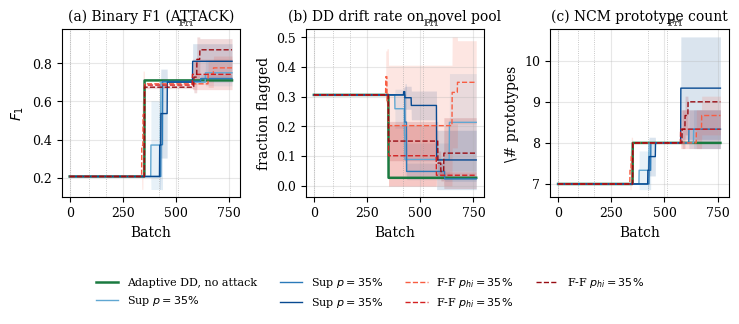

Saved rq3_dd_corruption_timeseries.{pdf,png}


In [13]:
def seed_mean_std(results_list, attr_path):
    """Stack seeds x batches, return (mean, std) per batch."""
    if attr_path.startswith('extras.'):
        key = attr_path.split('.', 1)[1]
        arr = np.array([[r.extras[key] for r in sr] for sr in results_list])
    else:
        arr = np.array([[getattr(r, attr_path) for r in sr] for sr in results_list])
    return arr.mean(axis=0), arr.std(axis=0)


day_starts = {}
for i, r in enumerate(baseline_adaptive_dd):
    if r.day_idx not in day_starts:
        day_starts[r.day_idx] = i

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.6))
cmap_supp = plt.cm.Blues
cmap_force = plt.cm.Reds
colors_supp = cmap_supp(np.linspace(0.35, 0.90, len(POISON_FRACS)))
colors_force = cmap_force(np.linspace(0.35, 0.90, len(POISON_FRACS)))

panel_specs = [
    ('f1', r'(a) Binary F1 (ATTACK)', r'$F_1$'),
    ('extras.dd_drift_rate_pool', r'(b) DD drift rate on novel pool', r'fraction flagged'),
    ('extras.n_prototypes', r'(c) NCM prototype count', r'\# prototypes'),
]
for ax, (attr, title, ylabel) in zip(axes, panel_specs):
    for day_idx, batch_idx in day_starts.items():
        ax.axvline(batch_idx, color='0.6', lw=0.6, ls=':', alpha=0.7)
    # Baselines
    if attr.startswith('extras.'):
        key = attr.split('.', 1)[1]
        if all(key in r.extras for r in baseline_adaptive_dd):
            ax.plot(
                [r.extras[key] for r in baseline_adaptive_dd],
                color='#1a7a40',
                lw=1.8,
                label='Adaptive DD, no attack',
            )
    else:
        ax.plot(
            [getattr(r, attr) for r in baseline_adaptive_dd],
            color='#1a7a40',
            lw=1.8,
            label='Adaptive DD, no attack',
        )
    # Suppress mode lines
    for idx, p in enumerate(POISON_FRACS[1:], 1):
        m, s = seed_mean_std(suppress_results[p], attr)
        xs = np.arange(len(m))
        ax.plot(
            xs, m, color=colors_supp[idx], lw=1.0, ls='-', label=f'Sup $p{{=}}{pfrac * 100:.0f}\\%$'
        )
        ax.fill_between(xs, m - s, m + s, color=colors_supp[idx], alpha=0.15, lw=0)
    # Force-false mode lines
    for idx, p in enumerate(POISON_FRACS[1:], 1):
        m, s = seed_mean_std(force_results[p], attr)
        xs = np.arange(len(m))
        ax.plot(
            xs,
            m,
            color=colors_force[idx],
            lw=1.0,
            ls='--',
            label=f'F-F $p_{{hi}}{{=}}{pfrac * 100:.0f}\\%$',
        )
        ax.fill_between(xs, m - s, m + s, color=colors_force[idx], alpha=0.15, lw=0)
    ax.set_xlabel('Batch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for xb, dname_idx in day_starts.items():
        ax.text(
            batch_idx + 2,
            1.01,
            DAY_NAMES[day_idx],
            fontsize=7,
            color='0.4',
            va='bottom',
            ha='left',
            transform=ax.get_xaxis_transform(),
        )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.25), frameon=False)
fig.tight_layout()
save_fig(fig, 'rq3_dd_corruption_timeseries', FIGURE_DIR)
plt.show()
print('Saved rq3_dd_corruption_timeseries.{pdf,png}')


## Latent-space visualisation


    [M 20/100] loss=0.4354


    [M 40/100] loss=0.4342


    [M 60/100] loss=0.4367


    [M 80/100] loss=0.4335


    [M 100/100] loss=0.4327
    [Contrastive 20/300] loss=11.3734


...

    [Contrastive 200/300] loss=1.1494
    [Contrastive 220/300] loss=1.0710


    [Contrastive 240/300] loss=1.1139
    [Contrastive 260/300] loss=0.9123


    [Contrastive 280/300] loss=0.8118
    [Contrastive 300/300] loss=0.7428


Running t-SNE (initial encoder)...


Running t-SNE (post-attack encoder)...


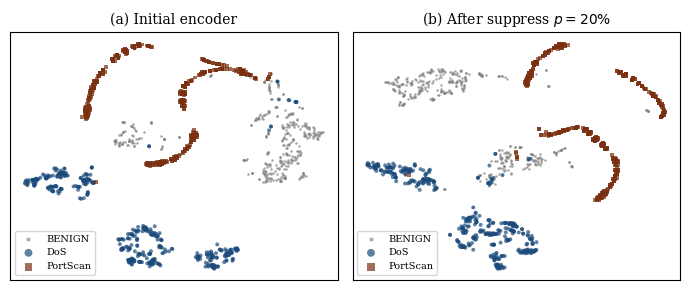

Saved rq3_latent_space.{pdf,png}


In [14]:
from sklearn.manifold import TSNE

P_REP = 0.20
seed_idx = 0  # first seed

# Initial-state encoder
det_init = ContrastiveNCMDetector(
    input_dim=data.input_dim,
    hidden_dim=64,
    latent_dim=32,
    temperature=0.1,
    device=DEVICE,
)
det_init.autoencoder.load_state_dict(copy.deepcopy(init.dd_init_ae))
det_init.ncm = copy.deepcopy(init.dd_init_ncm)

sys_final = fresh_adaptive_dd_adaptive_m()
_ = run_stream(
    sys_final,
    X_stream=split.X_stream,
    y_stream_bin=split.y_stream_bin,
    d_stream=split.d_stream,
    novel_pool=split.novel_pool,
    poison_frac=P_REP,
    rng_seed=SEEDS[seed_idx],
    batch_size=BATCH_SIZE,
)

# Sample for t-SNE: BENIGN + each novel class
SAMPLE_PER_CLASS = 400
_rng_t = np.random.default_rng(0)
benign_idx_all = np.where(data.y_all == data.benign_id)[0]
benign_sample = data.X[_rng_t.choice(benign_idx_all, SAMPLE_PER_CLASS, replace=False)]

novel_samples_by_class = {}
for cname in NOVEL_CLASSES:
    cid = data.le_full.transform([cname])[0]
    cls_idx_all = np.where(data.y_all == cid)[0]
    novel_samples_by_class[cname] = data.X[
        _rng_t.choice(cls_idx_all, SAMPLE_PER_CLASS, replace=False)
    ]


def encode_all(detector):
    with torch.no_grad():
        h_benign = detector.encode(torch.from_numpy(benign_sample)).cpu().numpy()
        h_novels = {
            c: detector.encode(torch.from_numpy(x)).cpu().numpy()
            for c, x in novel_samples_by_class.items()
        }
    return h_benign, h_novels


h_b_init, h_n_init = encode_all(det_init)
h_b_fin, h_n_fin = encode_all(sys_final.detector)


def project_combined(h_benign, h_novels):
    """Run t-SNE on combined embeddings, return per-class projections."""
    labels = ['BENIGN'] * len(h_benign)
    combined = [h_benign]
    for c, h in h_novels.items():
        combined.append(h)
        labels += [c] * len(h)
    arr = np.vstack(combined)
    proj = TSNE(n_components=2, init='pca', perplexity=30, random_state=0).fit_transform(arr)
    by_class = {'BENIGN': proj[np.array(labels) == 'BENIGN']}
    for c in h_novels:
        by_class[c] = proj[np.array(labels) == c]
    return by_class


print('Running t-SNE (initial encoder)...')
proj_init = project_combined(h_b_init, h_n_init)
print('Running t-SNE (post-attack encoder)...')
proj_fin = project_combined(h_b_fin, h_n_fin)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0))
for ax, (label, proj) in zip(
    axes,
    [
        ('(a) Initial encoder', proj_init),
        (f'(b) After suppress $p{{=}}{P_REP * 100:.0f}\\%$', proj_fin),
    ],
):
    ax.scatter(
        proj['BENIGN'][:, 0],
        proj['BENIGN'][:, 1],
        s=4,
        alpha=0.5,
        color='0.5',
        label='BENIGN',
        marker='.',
    )
    for c, marker, colour in zip(NOVEL_CLASSES, ['o', 's'], ['#1a4a7a', '#7a3010']):
        ax.scatter(
            proj[c][:, 0],
            proj[c][:, 1],
            s=8,
            alpha=0.7,
            color=colour,
            marker=marker,
            edgecolor='none',
            label=c,
        )
    ax.set_title(label)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(fontsize=7, markerscale=2, loc='best')

fig.tight_layout()
save_fig(fig, 'rq3_latent_space', FIGURE_DIR)
plt.show()
print('Saved rq3_latent_space.{pdf,png}')
